<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

In [ ]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.5 MB/s eta 0:00:00


In [ ]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [ ]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000


In [ ]:
s1Ascending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Ascending_2022")
s1Descending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Descending_2022")
DEMindices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/DEMindices_2022")
GEDIindicesA_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesA_2022")
GEDIindicesB_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesB_2022")
HLS_2022 = ee.Image("projects/servir-sco-assets/assets/PR/HLS_2022")
LandsatComposite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatComposite_2022")
LandsatIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatIndices_2022")
S2Composite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Composite_2022")
S2Indices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Indices_2022")
landsatTasseledCapIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/landsatTasseledCapIndices_2022")
ROI = ee.FeatureCollection('users/tjm0042/PHD/PR/GUAN_724000_1987000')

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2022, {}, 's1Ascending_2022')
Map.addLayer(s1Descending_2022, {}, 's1Descending_2022')
Map.addLayer(DEMindices_2022, {}, 'DEMindices_2022')
Map.addLayer(GEDIindicesA_2022, {}, 'GEDIindicesA_2022')
Map.addLayer(GEDIindicesB_2022, {}, 'GEDIindicesB_2022')
Map.addLayer(HLS_2022, {}, 'HLS_2022')
Map.addLayer(LandsatComposite_2022, {}, 'LandsatComposite_2022')
Map.addLayer(LandsatIndices_2022, {}, 'LandsatIndices_2022')
Map.addLayer(S2Composite_2022, {}, 'S2Composite_2022')
Map.addLayer(S2Indices_2022, {}, 'S2Indices_2022')
Map.addLayer(landsatTasseledCapIndices_2022, {}, 'landsatTasseledCapIndices_2022')


#stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(HLS_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(S2Composite_2022).addBands(S2Indices_2022).addBands(landsatTasseledCapIndices_2022)

stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)


#.addBands(GEDIindicesA_2022)
#.addBands(GEDIindicesB_2022)

Map.addLayer(stacked, {}, 'stacked');


Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [ ]:
y_stacked = GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")## GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())
#y_stacked = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())

Map.addLayer(y_stacked, {}, 'y_stacked');

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

# CNN Approach

In [ ]:
#
#https://code.earthengine.google.com/b8d2ad0de3f26da0ec5942c9260577db


def regrid(number, image_collection, resample_method):
    """
    Reprojects and resamples an ImageCollection to a coarser grid.

    Args:
        number (float): Desired scale in meters (e.g., 100).
        image_collection (ee.ImageCollection): The input collection.
        resample_method (str): Resampling method ('nearest', 'bilinear', 'bicubic').

    Returns:
        ee.Image: A single reprojected, resampled, and reduced image.
    """
    # Define projection at specified scale
    grid_projection = ee.Projection('EPSG:3857').atScale(number)

    # Mosaic and resample the collection
    stacked = image_collection.resample(resample_method)

    # Reduce resolution and reproject to new grid
    stacked_resampled = stacked.reduceResolution(
        reducer=ee.Reducer.mean(),
        maxPixels=1024
    ).reproject(crs=grid_projection)

    return stacked_resampled


In [ ]:
gridScale = 10

regrid_out = regrid(gridScale, stacked, 'bilinear')
y_regrid_out = regrid(gridScale, y_stacked, 'bilinear')
print(y_regrid_out.bandNames())

ee.List({
  "functionInvocationValue": {
    "functionName": "Image.bandNames",
    "arguments": {
      "image": {
        "functionInvocationValue": {
          "functionName": "Image.reproject",
          "arguments": {
            "crs": {
              "functionInvocationValue": {
                "functionName": "Projection.atScale",
                "arguments": {
                  "meters": {
                    "constantValue": 10
                  },
                  "projection": {
                    "functionInvocationValue": {
                      "functionName": "Projection",
                      "arguments": {
                        "crs": {
                          "constantValue": "EPSG:3857"
                        }
                      }
                    }
                  }
                }
              }
            },
            "image": {
              "functionInvocationValue": {
                "functionName": "Image.reduceResolution",
            

In [ ]:
stackedResampled = regrid_out.updateMask(regrid_out.mask().gt(0));

# y_stackedResampled = regrid_out#.updateMask(y_regrid_out.mask().gt(0));

# print(y_stackedResampled.bandNames())

#Visualize the resampled layers
Map.addLayer(stackedResampled, {}, 'stackedResampled_Regrid_Func');
# Map.addLayer(y_stackedResampled, {}, 'y_stackedResampled');
Map

Map(bottom=7537675.0, center=[17.96373116819307, -66.86958432197572], controls=(WidgetControl(options=['positi…

In [ ]:
# # // Extract Training Features
# # // ****************************************************

# predictors = s1Ascending_2022.bandNames().cat(s1Descending_2022.bandNames()).cat(DEMindices_2022.bandNames()).cat(HLS_2022.bandNames()).cat(LandsatComposite_2022.bandNames()).cat(LandsatIndices_2022.bandNames()).cat(S2Composite_2022.bandNames()).cat(S2Indices_2022.bandNames()).cat(landsatTasseledCapIndices_2022.bandNames())#//.cat(gediMosaicA.bandNames());
# print('predictors', predictors);


# predicted = GEDIindicesA_2022.select('rh.*').bandNames()#// | gediMosaicA..select('rh.*').bandNames(); //| ['rh10']///| gediMosaicA.bandNames();  //gediMosaicA.select('rh10').bandNames()//
# print('predicted', predicted);

# predicted_length =  predicted.length()
# print("predicted_length", predicted_length)

# predictorImage = stackedResampled.select(predictors);
# predictedImage = stackedResampled.select([predicted]).unmask();

In [ ]:
#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2022.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)


proj = s1Ascending_2022.projection()
grid = ROI.geometry().coveringGrid(proj, 10)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


print('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

spatial_partition number of boxes in the grid ee.Number({
  "functionInvocationValue": {
    "functionName": "Collection.size",
    "arguments": {
      "collection": {
        "functionInvocationValue": {
          "functionName": "Collection.randomColumn",
          "arguments": {
            "collection": {
              "functionInvocationValue": {
                "functionName": "Geometry.coveringGrid",
                "arguments": {
                  "geometry": {
                    "functionInvocationValue": {
                      "functionName": "Collection.geometry",
                      "arguments": {
                        "collection": {
                          "functionInvocationValue": {
                            "functionName": "Collection.loadTable",
                            "arguments": {
                              "tableId": {
                                "constantValue": "users/tjm0042/PHD/PR/GUAN_724000_1987000"
                              }
     

Map(bottom=7537675.0, center=[17.96373116819307, -66.86958432197572], controls=(WidgetControl(options=['positi…

In [ ]:
# function sample_partition(Image, Labeled_Image, total_samples, region, gridScale, numnonSamples, numSamples) {
#     var sample_partition_out = Image.addBands(Labeled_Image)
#     .stratifiedSample({
#       numPoints: total_samples,
#       classBand: 'class',
#       region: region,
#       scale: gridScale,
#       seed: 42,
#       classValues: [0, 1],
#       classPoints: [numnonSamples, numSamples],
#       dropNulls: true,
#       tileScale: 16,
#       geometries:true
#   }).randomColumn();
# return ee.FeatureCollection(sample_partition_out)
# }


# def sample_partition (Image, Labeled_Image, total_samples, region, grid_scale, numnon_samples, num_samples):
#   sample_partition_out = Image.addBands(Labeled_Image)

#   sample_partition_out

# return

In [ ]:
# import ee
# import geemap
# import numpy as np
# import matplotlib.pyplot as plt

# img = ee.Image('LANDSAT/LC08/C02/T1/LC08_031032_20130402') \
#   .select(['B4', 'B5', 'B6'])

# aoi = ee.Geometry.Polygon(
#   [[[-102.37, 40.02],
#     [-102.37, 40.02],
#     [-102.61, 40.17],
#     [-102.61, 40.17]]], None, False)

# rgb_img = geemap.ee_to_numpy(img, region=aoi)
# print(rgb_img.shape)

# rgb_img_test = (255*((rgb_img[:, :, 0:3] - 100)/3500)).astype('uint8')
# plt.imshow(rgb_img_test)
# plt.show()

In [ ]:
training = geemap.ee_to_numpy(stackedResampled, region=train_samp)
print(training.shape)
# print(training)

testing = geemap.ee_to_numpy(stackedResampled, region=test_samp)
print(testing.shape)
# print(testing)

validation = geemap.ee_to_numpy(stackedResampled, region=val_samp)
print(validation.shape)
# print(validation)


(108, 107, 45)
(108, 107, 45)
(108, 107, 45)


In [ ]:
y = geemap.ee_to_numpy(y_regrid_out, region=train_samp)
print(y.shape)


(108, 107, 1)


In [ ]:


X_cnn_train = training.reshape((1, 108, 107, 45))  # (batch_size, height, width, channels)
print("X_cnn_train", X_cnn_train.shape)

X_cnn_test = testing.reshape((1, 108, 107, 45))  # (batch_size, height, width, channels)
print("X_cnn_test", X_cnn_test.shape)

X_cnn_val = validation.reshape((1, 108, 107, 45))  # (batch_size, height, width, channels)
print("X_cnn_val", X_cnn_val.shape)


# If y is per-pixel:
y_cnn = y.reshape((1, 108, 107, 1))   # Add channel for consistency
print("y_cnn", y_cnn.shape)

X_cnn_train (1, 108, 107, 45)
X_cnn_test (1, 108, 107, 45)
X_cnn_val (1, 108, 107, 45)
y_cnn (1, 108, 107, 1)


In [ ]:
# import numpy as np

# # Example input
# arr = y_cnn
# # Reshape to (108, 107)
# reshaped_arr = np.squeeze(arr)

# # print(reshaped_arr.shape)  # Output: (108, 107)

# qq = pd.DataFrame(reshaped_arr)
# # print(qq)
# print(qq.describe())

         0      1      2      3      4      5      6      7           8    \
count  108.0  108.0  108.0  108.0  108.0  108.0  108.0  108.0  108.000000   
mean     0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.063388   
std      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.376754   
min      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.000000   
25%      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.000000   
50%      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.000000   
75%      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.000000   
max      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    2.281951   

              9    ...         97          98          99     100    101  \
count  108.000000  ...  108.000000  108.000000  108.000000  108.0  108.0   
mean     0.063388  ...    0.108016    0.066098    0.066098    0.0    0.0   
std      0.376754  ...    0.453999    0.392868    0.392868    0.0    0.0   
mi

Epoch 1/100
1/1 - 2s - 2s/step - loss: 1070663.5000 - mae: 1026.4323 - r2_metric: -8.4253e+06 - val_loss: 74234.3047 - val_mae: 253.2822 - val_r2_metric: -5.8417e+05
Epoch 2/100
1/1 - 0s - 334ms/step - loss: 74234.3047 - mae: 253.2822 - r2_metric: -5.8417e+05 - val_loss: 485669.9375 - val_mae: 686.5769 - val_r2_metric: -3.8218e+06
Epoch 3/100
1/1 - 0s - 287ms/step - loss: 485669.9375 - mae: 686.5769 - r2_metric: -3.8218e+06 - val_loss: 375526.3125 - val_mae: 603.0514 - val_r2_metric: -2.9551e+06
Epoch 4/100
1/1 - 0s - 286ms/step - loss: 375526.3125 - mae: 603.0514 - r2_metric: -2.9551e+06 - val_loss: 90392.3125 - val_mae: 287.9392 - val_r2_metric: -7.1132e+05
Epoch 5/100
1/1 - 0s - 296ms/step - loss: 90392.3125 - mae: 287.9392 - r2_metric: -7.1132e+05 - val_loss: 10393.0664 - val_mae: 92.5265 - val_r2_metric: -8.1784e+04
Epoch 6/100
1/1 - 0s - 301ms/step - loss: 10393.0664 - mae: 92.5265 - r2_metric: -8.1784e+04 - val_loss: 120048.1406 - val_mae: 338.8035 - val_r2_metric: -9.4468e+05
E

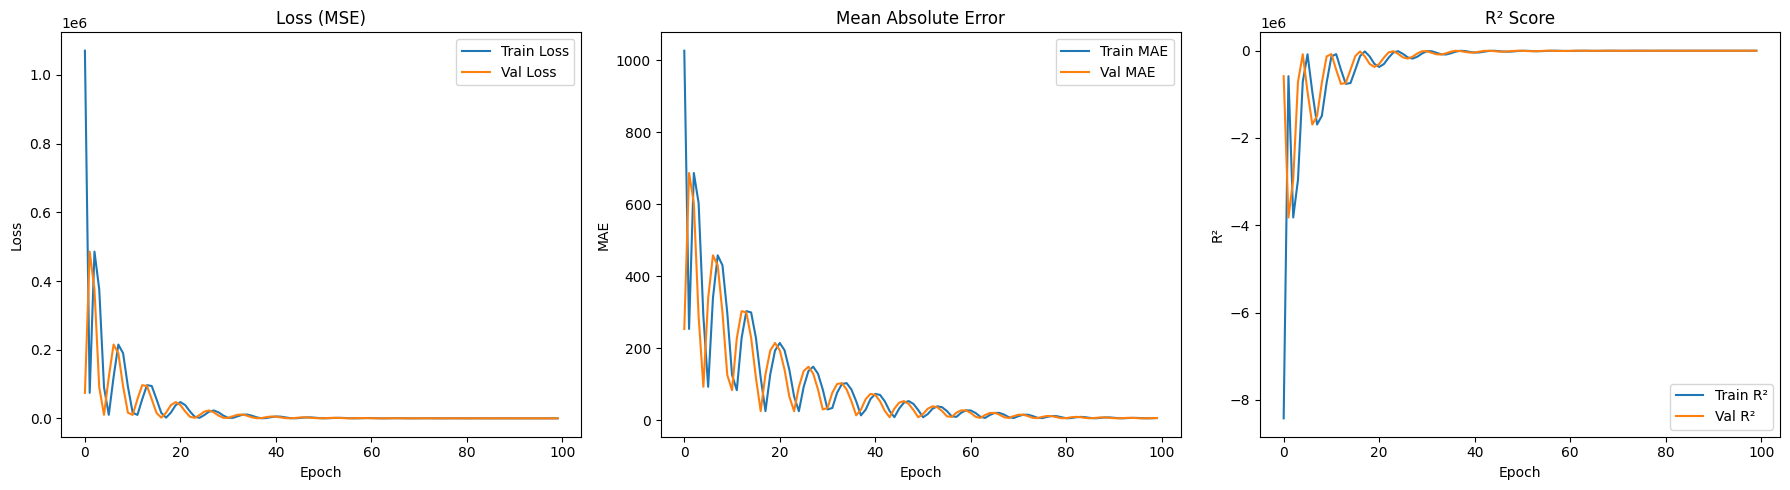

🛰️ Making spatial prediction on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


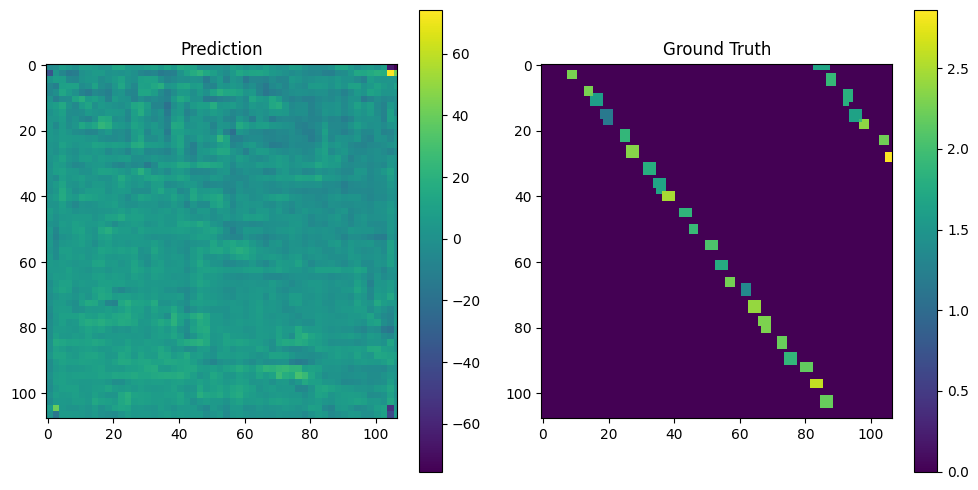

In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import numpy as np

# --- Custom R² Metric ---
def r2_metric(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# --- Define CNN Model ---
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(108, 107, 45)),
        tf.keras.layers.MaxPooling2D((2, 2), padding='same'),  # → (54, 54)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.UpSampling2D((2, 2)),                  # → (108, 108)
        tf.keras.layers.Cropping2D(((0, 0), (0, 1))),          # → (108, 107)
        tf.keras.layers.Conv2D(1, (1, 1), activation='linear', padding='same')  # Output: regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae', r2_metric])
    return model

# --- Model Setup ---
model = create_model()

# --- Training ---
history = model.fit(
    X_cnn_train, y_cnn,
    validation_data=(X_cnn_val, y_cnn),
    epochs=100,
    verbose=2
)

# --- Evaluation ---
print("📈 Evaluating on training set:")
train_metrics = model.evaluate(X_cnn_train, y_cnn, verbose=0)

print("\n📊 Evaluating on test set:")
test_metrics = model.evaluate(X_cnn_test, y_cnn, verbose=0)

print("\n✅ Evaluating on validation set:")
val_metrics = model.evaluate(X_cnn_val, y_cnn, verbose=0)

print(f"""
🔎 Final Evaluation:
- Train Loss: {train_metrics[0]:.4f} | MAE: {train_metrics[1]:.4f} | R²: {train_metrics[2]:.4f}
- Test  Loss: {test_metrics[0]:.4f} | MAE: {test_metrics[1]:.4f} | R²: {test_metrics[2]:.4f}
- Val   Loss: {val_metrics[0]:.4f} | MAE: {val_metrics[1]:.4f} | R²: {val_metrics[2]:.4f}
""")

# --- Training Performance Plots ---
plt.figure(figsize=(18, 5))

# Loss Plot
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE Plot
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

# R² Plot
plt.subplot(1, 3, 3)
plt.plot(history.history['r2_metric'], label='Train R²')
plt.plot(history.history['val_r2_metric'], label='Val R²')
plt.title('R² Score')
plt.xlabel('Epoch')
plt.ylabel('R²')
plt.legend()

plt.tight_layout()
plt.show()

# --- Spatial Prediction on New Image (Test Set) ---
print("🛰️ Making spatial prediction on test set...")
y_pred = model.predict(X_cnn_test)

# --- Visual Comparison ---
def show_prediction(pred, truth, title_pred="Prediction", title_truth="Ground Truth"):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(pred[0, :, :, 0], cmap='viridis')
    plt.title(title_pred)
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(truth[0, :, :, 0], cmap='viridis')
    plt.title(title_truth)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

show_prediction(y_pred, y_cnn)


# Fusion

In [ ]:
#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2022.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)


proj = s1Ascending_2022.projection()
grid = ROI.geometry().coveringGrid(proj, 10)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

Map(bottom=1884617.0, center=[17.965915201477674, -66.87798500061037], controls=(WidgetControl(options=['posit…

In [ ]:
training = geemap.ee_to_numpy(stacked, region=train_samp)
print(training.shape)
# print(training)

testing = geemap.ee_to_numpy(stacked, region=test_samp)
print(testing.shape)
# print(testing)

validation = geemap.ee_to_numpy(stacked, region=val_samp)
print(validation.shape)
# print(validation)

(102, 107, 45)
(102, 107, 45)
(102, 107, 45)


In [ ]:
y_stacked = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
#print(y_stacked.bandNames())

# Map.addLayer(y_stacked, {}, 'y_stacked');

# Map


In [ ]:
y_trainining = geemap.ee_to_numpy(y_stacked, region=train_samp)
print(y_trainining.shape)
# print(validation)

y_testing = geemap.ee_to_numpy(y_stacked, region=test_samp)
print(y_testing.shape)
# print(validation)

y_validation = geemap.ee_to_numpy(y_stacked, region=val_samp)
print(y_validation.shape)
# print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add
# from tensorflow.keras.optimizers import Adam
# from sklearn.metrics import mean_squared_error, r2_score


# # Mock input data for demonstration
# X_train = training
# print(X_train.shape)
# y_train = y_trainining
# print(y_train.shape)
# X_test = testing
# print(X_test.shape)
# y_test = y_testing
# print(y_test.shape)
# X_val = validation
# print(X_val.shape)
# y_val = y_validation
# print(y_val.shape)



# def sanitize_array(arr):
#     arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
#     arr = np.clip(arr, -1e5, 1e5)  # Adjust this range as appropriate for your domain
#     return arr.astype(np.float32)


# X_train = sanitize_array(X_train)
# X_test = sanitize_array(X_test)
# X_val = sanitize_array(X_val)
# y_train = sanitize_array(y_train)
# y_test = sanitize_array(y_test)
# y_val = sanitize_array(y_val)




# # Pad X data so the output can match 103x103
# def pad_input(X):
#     return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

# X_train = pad_input(X_train)
# X_test = pad_input(X_test)
# X_val = pad_input(X_val)
# y_train = np.expand_dims(y_train, axis=0)
# y_test = np.expand_dims(y_test, axis=0)
# y_val = np.expand_dims(y_val, axis=0)

# # Split inputs for mid and late fusion
# def split_inputs(X):
#     SAR = X[:, :, :, 0:8]
#     dem = X[:, :, :, 8:10]
#     landsat = X[:, :, :, 10:33]
#     sentinel_2 = X[:, :, :, 33:45]
#     return SAR, dem, landsat, sentinel_2

# # Model builders
# def build_early_fusion(input_shape):
#     inputs = Input(shape=input_shape)
#     x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model(inputs, x)

# def build_mid_fusion():
#     input_SAR = Input(shape=(103, 107, 8))
#     input_dem = Input(shape=(103, 107, 2))
#     input_landsat = Input(shape=(103, 107, 23))
#     input_sentinel_2 = Input(shape=(103, 107, 12))

#     def block(x):
#         x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
#         x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#         return x

#     x1 = block(input_SAR)
#     x2 = block(input_dem)
#     x3 = block(input_landsat)
#     x4 = block(input_sentinel_2)

#     x = Concatenate()([x1, x2, x3, x4])
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

# def build_late_fusion():
#     # input_sentinel = Input(shape=(103, 107, 20))
#     # input_dem = Input(shape=(103, 107, 2))
#     # input_landsat = Input(shape=(103, 107, 23))
#     input_SAR = Input(shape=(103, 107, 8))
#     input_dem = Input(shape=(103, 107, 2))
#     input_landsat = Input(shape=(103, 107, 23))
#     input_sentinel_2 = Input(shape=(103, 107, 12))

#     def block(x):
#         x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
#         x = Cropping2D(((0, 0), (2, 2)))(x)
#         return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

#     y1 = block(input_SAR)
#     y2 = block(input_dem)
#     y3 = block(input_landsat)
#     y4 = block(input_sentinel_2)

#     y = Add()([y1, y2, y3, y4])
#     y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
#     return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)

# def compile_and_train(model, X, y, name):
#     model.compile(optimizer=Adam(), loss='mse')
#     history = model.fit(X, y, epochs=10, verbose=1)
#     y_pred = model.predict(X)

#     mse = mean_squared_error(y.flatten(), y_pred.flatten())
#     r2 = r2_score(y.flatten(), y_pred.flatten())
#     print(f"{name}-fusion MSE: {mse:.4f}, R^2: {r2:.4f}")

#     plt.plot(history.history['loss'])
#     plt.title(f'{name}-Fusion Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.show()

#     plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
#     plt.title(f'{name}-Fusion Prediction')
#     plt.colorbar()
#     plt.show()

# # Train and evaluate models
# model_early = build_early_fusion((103, 107, 45))
# compile_and_train(model_early, X_train, y_train, 'Early')

# sentinel_SAR, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
# model_mid = build_mid_fusion()
# compile_and_train(model_mid, [sentinel_SAR, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

# model_late = build_late_fusion()
# compile_and_train(model_late, [sentinel_SAR, dem_train, landsat_train, sentinel_train], y_train, 'Late')

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0726
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.3900
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.1049
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0756
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0824
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0694
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.0651
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.0672
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0657
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.0647
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.0654
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 0.0649
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.0645
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.0650
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.0647
Epoch 1

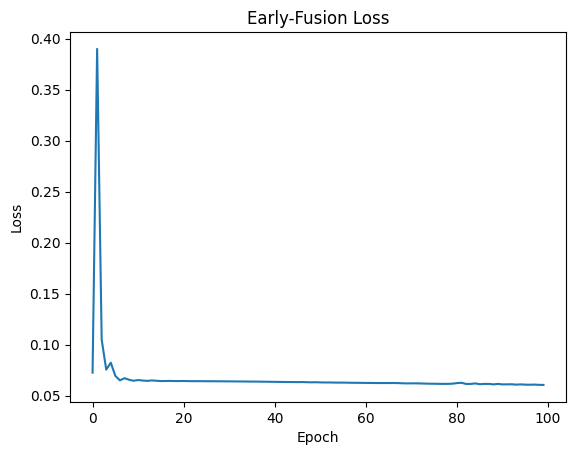

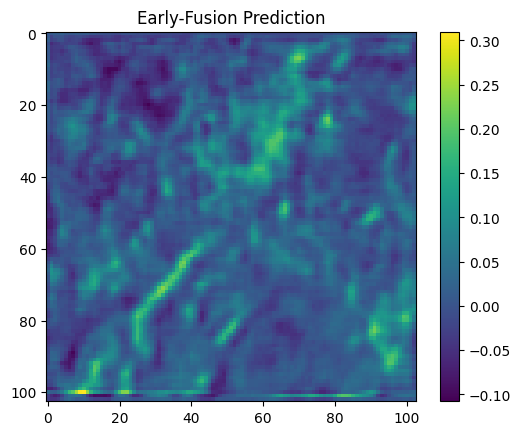

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0784
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 0.1912
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - loss: 0.0863
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.0674
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 0.0884
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 0.0912
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 0.0812
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 0.0711
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 0.0660
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 0.0645
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - loss: 0.0649
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - loss: 0.0654
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - loss: 0.0655
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - loss: 0.0655
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step - loss: 0.0654
Epoch 1

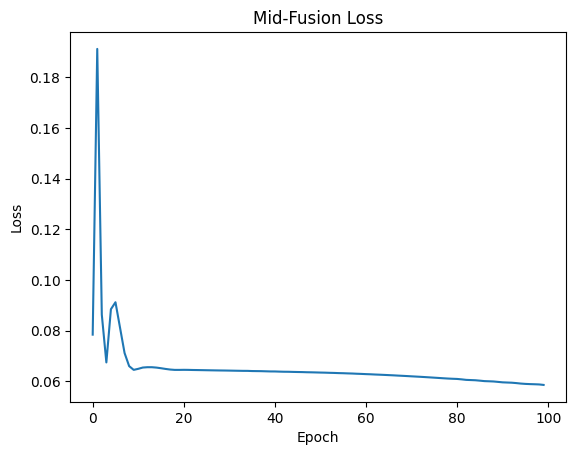

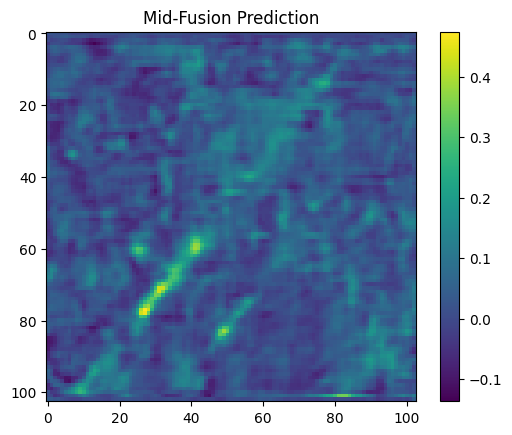

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1966
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.4769
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1254
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.3761
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.2390
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 0.1112
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - loss: 0.1967
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.2321
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1458
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0967
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.1420
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.1761
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.1391
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0968
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1103
Epoch 1

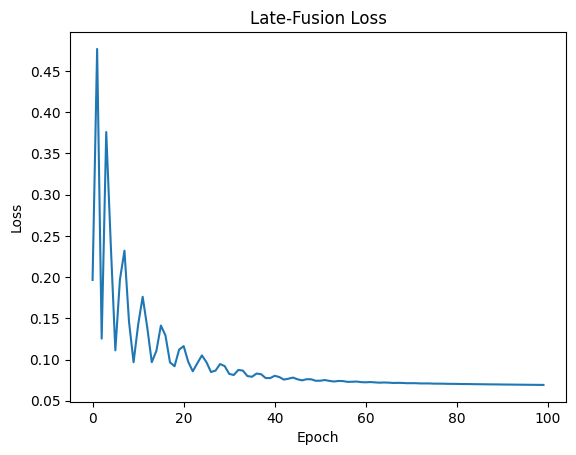

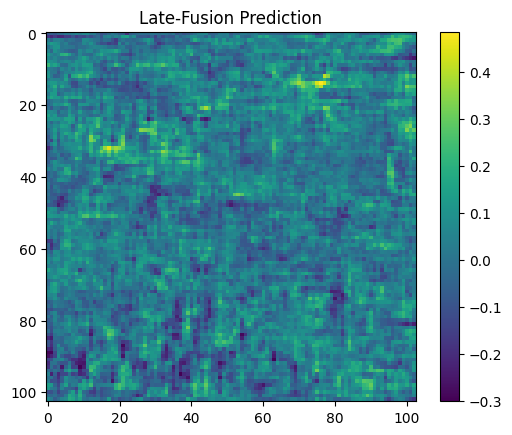

In [ ]:
# this block includes scaling acorss all avaiable bands

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# --- Load your training, testing, validation arrays ---
X_train = training
y_train = y_trainining
X_test = testing
y_test = y_testing
X_val = validation
y_val = y_validation

# -------------------------------
# Sanitize X and Y arrays
# -------------------------------
def sanitize_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr = np.clip(arr, -1e5, 1e5)
    return arr.astype(np.float32)

X_train = sanitize_array(X_train)
X_test = sanitize_array(X_test)
X_val = sanitize_array(X_val)
y_train = sanitize_array(y_train)
y_test = sanitize_array(y_test)
y_val = sanitize_array(y_val)

# -------------------------------
# Per-band MinMax scaling for X
# -------------------------------
def scale_per_band(X_train, X_test, X_val):
    n_bands = X_train.shape[-1]
    X_train_scaled = np.zeros_like(X_train)
    X_test_scaled = np.zeros_like(X_test)
    X_val_scaled = np.zeros_like(X_val)

    for i in range(n_bands):
        scaler = MinMaxScaler()
        train_band = X_train[:, :, i].reshape(-1, 1)
        test_band = X_test[:, :, i].reshape(-1, 1)
        val_band = X_val[:, :, i].reshape(-1, 1)

        scaler.fit(train_band)

        X_train_scaled[:, :, i] = scaler.transform(train_band).reshape(X_train.shape[0], X_train.shape[1])
        X_test_scaled[:, :, i] = scaler.transform(test_band).reshape(X_test.shape[0], X_test.shape[1])
        X_val_scaled[:, :, i] = scaler.transform(val_band).reshape(X_val.shape[0], X_val.shape[1])

    return X_train_scaled, X_test_scaled, X_val_scaled

X_train, X_test, X_val = scale_per_band(X_train, X_test, X_val)

# -------------------------------
# Pad X data to match output size
# -------------------------------
def pad_input(X):
    return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

X_train = pad_input(X_train)
X_test = pad_input(X_test)
X_val = pad_input(X_val)
y_train = np.expand_dims(y_train, axis=0)
y_test = np.expand_dims(y_test, axis=0)
y_val = np.expand_dims(y_val, axis=0)

# -------------------------------
# Split inputs for mid and late fusion
# -------------------------------
def split_inputs(X):
    SAR = X[:, :, :, 0:8]
    dem = X[:, :, :, 8:10]
    landsat = X[:, :, :, 10:33]
    sentinel_2 = X[:, :, :, 33:45]
    return SAR, dem, landsat, sentinel_2

# -------------------------------
# Model builders (same as before)
# -------------------------------
def build_early_fusion(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model(inputs, x)

def build_mid_fusion():
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        return x

    x1 = block(input_SAR)
    x2 = block(input_dem)
    x3 = block(input_landsat)
    x4 = block(input_sentinel_2)

    x = Concatenate()([x1, x2, x3, x4])
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], x)

def build_late_fusion():
    input_SAR = Input(shape=(103, 107, 8))
    input_dem = Input(shape=(103, 107, 2))
    input_landsat = Input(shape=(103, 107, 23))
    input_sentinel_2 = Input(shape=(103, 107, 12))

    def block(x):
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
        x = Cropping2D(((0, 0), (2, 2)))(x)
        return Conv2D(1, (1, 1), activation='linear', padding='same')(x)

    y1 = block(input_SAR)
    y2 = block(input_dem)
    y3 = block(input_landsat)
    y4 = block(input_sentinel_2)

    y = Add()([y1, y2, y3, y4])
    y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
    return Model([input_SAR, input_dem, input_landsat, input_sentinel_2], y)

# -------------------------------
# Compile and train models
# -------------------------------
def compile_and_train(model, X, y, name):
    model.compile(optimizer=Adam(), loss='mse')
    history = model.fit(X, y, epochs=100, verbose=1)
    y_pred = model.predict(X)

    mse = mean_squared_error(y.flatten(), y_pred.flatten())
    r2 = r2_score(y.flatten(), y_pred.flatten())
    print(f"{name}-fusion MSE: {mse:.4f}, R^2: {r2:.4f}")

    plt.plot(history.history['loss'])
    plt.title(f'{name}-Fusion Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
    plt.title(f'{name}-Fusion Prediction')
    plt.colorbar()
    plt.show()

# -------------------------------
# Train models
# -------------------------------
model_early = build_early_fusion((103, 107, 45))
compile_and_train(model_early, X_train, y_train, 'Early')

SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
model_mid = build_mid_fusion()
compile_and_train(model_mid, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Mid')

model_late = build_late_fusion()
compile_and_train(model_late, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, 'Late')


Viz


----- Early Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Early MSE: 0.0607
Early RMSE: 0.2464
Early MAE: 0.0631
Early R²: 0.0572


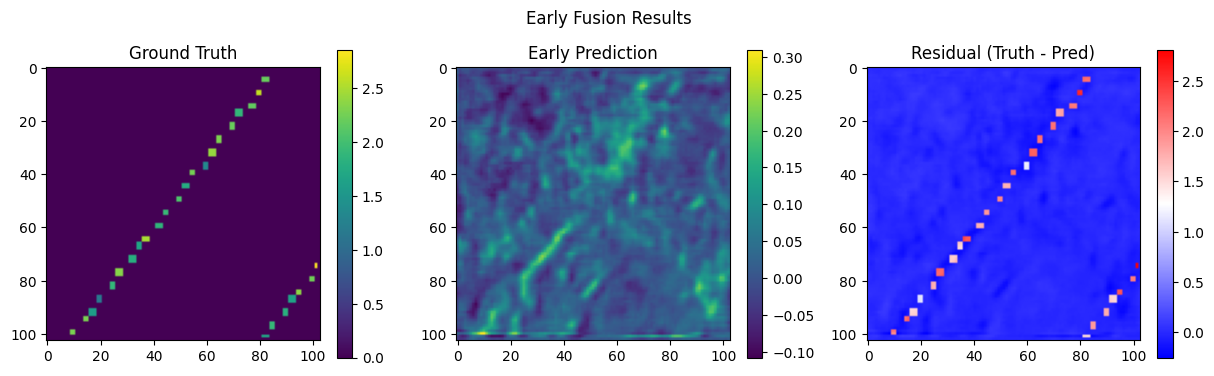


----- Mid Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Mid MSE: 0.0583
Mid RMSE: 0.2415
Mid MAE: 0.0737
Mid R²: 0.0940


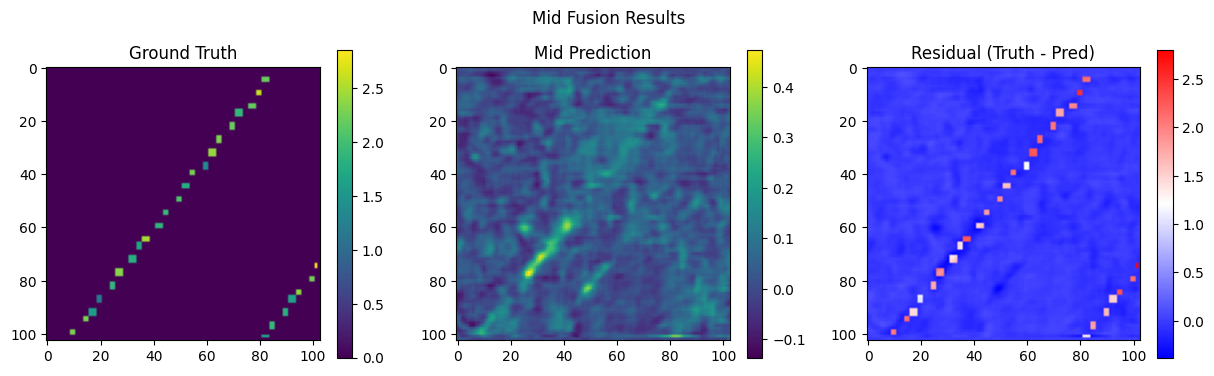


----- Late Fusion Evaluation -----
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Late MSE: 0.0692
Late RMSE: 0.2630
Late MAE: 0.1017
Late R²: -0.0740


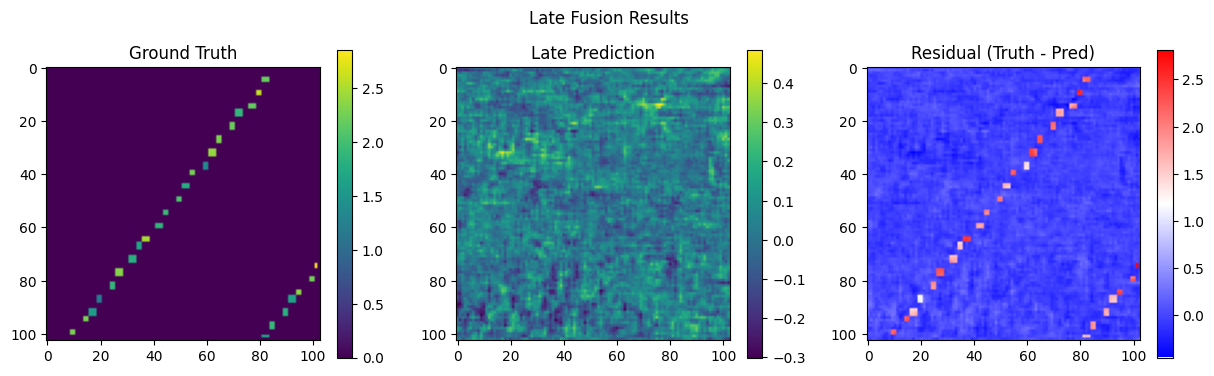

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def visualize_predictions(model, X_input, y_true, name):
    print(f"\n----- {name} Fusion Evaluation -----")

    # Predict
    y_pred = model.predict(X_input)

    # Flatten for stats
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Metrics
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)

    print(f"{name} MSE: {mse:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} MAE: {mae:.4f}")
    print(f"{name} R²: {r2:.4f}")

    # Visualize
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(y_true[0, :, :, 0], cmap='viridis')
    plt.title('Ground Truth')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
    plt.title(f'{name} Prediction')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow((y_true[0, :, :, 0] - y_pred[0, :, :, 0]), cmap='bwr')
    plt.title('Residual (Truth - Pred)')
    plt.colorbar()

    plt.suptitle(f'{name} Fusion Results')
    plt.show()

# --- Run for Early ---
visualize_predictions(model_early, X_test, y_test, 'Early')

# --- Run for Mid ---
SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
visualize_predictions(model_mid, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Mid')

# --- Run for Late ---
visualize_predictions(model_late, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Late')
